In [2]:
from google.colab import drive
from pathlib import Path

# Use a fresh mount point
MOUNT_POINT = "/content/exp5_drive"

if not Path(MOUNT_POINT).exists():
    drive.mount(MOUNT_POINT)
elif not any(Path(MOUNT_POINT).iterdir()):
    drive.mount(MOUNT_POINT)

DRIVE_MOUNT = Path(MOUNT_POINT)

print("✅ Drive location:", DRIVE_MOUNT)

Mounted at /content/exp5_drive
✅ Drive location: /content/exp5_drive


In [3]:
SHORTCUT_ID = "1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL"

shortcut_root = (
    DRIVE_MOUNT
    / ".shortcut-targets-by-id"
    / SHORTCUT_ID
    / "Applied Data Science Project"
)

mydrive_root = (
    DRIVE_MOUNT
    / "MyDrive"
    / "Applied Data Science Project"
)

if shortcut_root.exists():
    PROJECT_ROOT = shortcut_root

elif mydrive_root.exists():
    PROJECT_ROOT = mydrive_root

else:
    raise FileNotFoundError(
        "Applied Data Science Project folder not found."
    )

EXP5_NOTEBOOK = (
    PROJECT_ROOT /
    "ADS_EXP_5.ipynb"
)

REPORT_DIR = (
    PROJECT_ROOT /
    "reports/exp5"
)

FIGURE_DIR = (
    REPORT_DIR /
    "figures"
)

print("✅ PROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nTarget notebook:")
print(EXP5_NOTEBOOK)

✅ PROJECT_ROOT:
/content/exp5_drive/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project

Target notebook:
/content/exp5_drive/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/ADS_EXP_5.ipynb


In [1]:
from pathlib import Path
import shutil

EXP5_NOTEBOOK = (
    PROJECT_ROOT /
    "ADS_EXP_5.ipynb"
)

print("Target:")
print(EXP5_NOTEBOOK)

matches = [
    p for p in DRIVE_MOUNT.rglob("ADS_EXP_5.ipynb")
]

print("\nFound copies:", len(matches))

for p in matches:
    print("•", p)

if matches:

    source = matches[0]

    if source.resolve() != EXP5_NOTEBOOK.resolve():
        shutil.copy2(
            source,
            EXP5_NOTEBOOK
        )

    print(
        "\n✅ Final notebook exists:",
        EXP5_NOTEBOOK.exists()
    )

else:
    print(
        "\n❌ Notebook is still not saved in Google Drive."
    )

NameError: name 'PROJECT_ROOT' is not defined

In [ ]:
from pathlib import Path

SHORTCUT_ID = (
    "1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL"
)

# Primary location: actual shortcut target
shortcut_project = (
    DRIVE_MOUNT /
    ".shortcut-targets-by-id" /
    SHORTCUT_ID /
    "Applied Data Science Project"
)

# Secondary fallback
mydrive_project = (
    DRIVE_MOUNT /
    "MyDrive" /
    "Applied Data Science Project"
)

if shortcut_project.exists():

    PROJECT_ROOT = shortcut_project
    print("✅ Project found through shortcut target.")

elif mydrive_project.exists():

    PROJECT_ROOT = mydrive_project
    print("✅ Project found in MyDrive.")

else:

    raise FileNotFoundError(
        "Applied Data Science Project could not be found "
        "after properly mounting Google Drive."
    )

DATA_PATH = (
    PROJECT_ROOT /
    "data/processed/loan_cleaned_exp2.csv"
)

MODEL_PATH = (
    PROJECT_ROOT /
    "models/exp4/best_loan_approval_model.joblib"
)

REPORT_DIR = (
    PROJECT_ROOT /
    "reports/exp5"
)

FIGURE_DIR = (
    REPORT_DIR /
    "figures"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\nPROJECT ROOT:")
print(PROJECT_ROOT)

print("\n" + "=" * 70)
print("EXPERIMENT 5 FILE CHECK")
print("=" * 70)

print(
    "✅" if PROJECT_ROOT.exists() else "❌",
    "Project"
)

print(
    "✅" if DATA_PATH.exists() else "❌",
    "Cleaned Dataset"
)

print(
    "✅" if MODEL_PATH.exists() else "❌",
    "Experiment 4 Best Model"
)

print(
    "✅" if REPORT_DIR.exists() else "❌",
    "Experiment 5 Reports Folder"
)

✅ Project found through shortcut target.

PROJECT ROOT:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project

EXPERIMENT 5 FILE CHECK
✅ Project
✅ Cleaned Dataset
✅ Experiment 4 Best Model
✅ Experiment 5 Reports Folder


In [ ]:
%pip install -q lime shap fairlearn

print("✅ Installation completed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 14.6 MB/s eta 0:00:00
✅ Installation completed


In [ ]:
import shap
import lime
import fairlearn

from lime.lime_tabular import LimeTabularExplainer

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference
)

print("✅ SHAP:", shap.__version__)
print("✅ LIME imported successfully")
print("✅ Fairlearn:", fairlearn.__version__)

✅ SHAP: 0.52.0
✅ LIME imported successfully
✅ Fairlearn: 0.14.0


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Verify paths created earlier
print("Dataset:", DATA_PATH)
print("Model:", MODEL_PATH)

print(
    "\nDataset exists:",
    DATA_PATH.exists()
)

print(
    "Model exists:",
    MODEL_PATH.exists()
)

# Load Experiment 2 cleaned dataset
df = pd.read_csv(DATA_PATH)

# Load Experiment 4 best model
best_model = joblib.load(MODEL_PATH)

print("\n" + "=" * 65)
print("EXPERIMENT 5 ENVIRONMENT READY")
print("=" * 65)

print("Dataset shape:", df.shape)
print("Model:", type(best_model).__name__)

print("\n✅ Dataset loaded")
print("✅ Best model loaded")
print("✅ SHAP ready")
print("✅ LIME ready")
print("✅ Fairlearn ready")

Dataset: /content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/data/processed/loan_cleaned_exp2.csv
Model: /content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/models/exp4/best_loan_approval_model.joblib

Dataset exists: True
Model exists: True

EXPERIMENT 5 ENVIRONMENT READY
Dataset shape: (499337, 20)
Model: Pipeline

✅ Dataset loaded
✅ Best model loaded
✅ SHAP ready
✅ LIME ready
✅ Fairlearn ready


In [ ]:
TARGET = "approval_label"

numeric_features = [
    "loan_amount",
    "risk_score",
    "dti",
    "employment_years",
    "application_year",
    "application_month",
    "application_quarter"
]

categorical_features = [
    "purpose",
    "state"
]

feature_columns = (
    numeric_features +
    categorical_features
)

X = df[feature_columns].copy()
y = df[TARGET].astype(int)

# Same split used in Experiment 4
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 65)
print("EXPERIMENT 5 DATA PREPARATION")
print("=" * 65)

print("Full dataset :", X.shape)
print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)

print("\nFeatures used:")
for feature in feature_columns:
    print("•", feature)

# Verify loaded model performance
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(
    X_test
)[:, 1]

print(
    "\nLoaded model accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred
        ),
        4
    )
)

print("✅ Exact Experiment 4 split recreated.")

EXPERIMENT 5 DATA PREPARATION
Full dataset : (499337, 9)
Training set : (399469, 9)
Testing set  : (99868, 9)

Features used:
• loan_amount
• risk_score
• dti
• employment_years
• application_year
• application_month
• application_quarter
• purpose
• state

Loaded model accuracy: 0.9638
✅ Exact Experiment 4 split recreated.


In [ ]:
print("Pipeline steps:")
print(best_model.named_steps.keys())

# Extract fitted preprocessing pipeline
preprocessor_exp5 = (
    best_model.named_steps["preprocessor"]
)

classifier_exp5 = (
    best_model.named_steps["classifier"]
)

print(
    "\nFinal classifier:",
    type(classifier_exp5).__name__
)

# Apply preprocessing already learned during Experiment 4
X_test_transformed = (
    preprocessor_exp5.transform(X_test)
)

# Get transformed feature names
feature_names_shap = (
    preprocessor_exp5
    .get_feature_names_out()
)

# Make names easier to read
feature_names_shap = [
    str(name)
    .replace("num__", "")
    .replace("cat__", "")
    for name in feature_names_shap
]

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names_shap,
    index=X_test.index
)

print(
    "\nOriginal features:",
    X_test.shape[1]
)

print(
    "Transformed features:",
    X_test_transformed_df.shape[1]
)

print(
    "Transformed test records:",
    X_test_transformed_df.shape[0]
)

print("\nExample transformed features:")
print(
    feature_names_shap[:20]
)

print("\n✅ Data ready for SHAP.")

Pipeline steps:
dict_keys(['preprocessor', 'classifier'])

Final classifier: HistGradientBoostingClassifier

Original features: 9
Transformed features: 72
Transformed test records: 99868

Example transformed features:
['numeric__loan_amount', 'numeric__risk_score', 'numeric__dti', 'numeric__employment_years', 'numeric__application_year', 'numeric__application_month', 'numeric__application_quarter', 'categorical__purpose_car', 'categorical__purpose_credit_card', 'categorical__purpose_debt_consolidation', 'categorical__purpose_educational', 'categorical__purpose_home_improvement', 'categorical__purpose_house', 'categorical__purpose_major_purchase', 'categorical__purpose_medical', 'categorical__purpose_moving', 'categorical__purpose_other', 'categorical__purpose_renewable_energy', 'categorical__purpose_small_business', 'categorical__purpose_vacation']

✅ Data ready for SHAP.


In [ ]:
# Use a sample to keep SHAP fast
SHAP_SAMPLE_SIZE = min(
    1000,
    len(X_test_transformed_df)
)

X_shap = (
    X_test_transformed_df
    .sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=42
    )
)

print(
    "SHAP sample:",
    X_shap.shape
)

# Tree-based SHAP explainer
shap_explainer = shap.TreeExplainer(
    classifier_exp5
)

shap_values = shap_explainer(
    X_shap
)

print("\nSHAP values generated.")

print(
    "SHAP values shape:",
    shap_values.values.shape
)

print(
    "Input shape:",
    X_shap.shape
)

# Verify consistency
if (
    shap_values.values.shape[1]
    == X_shap.shape[1]
):
    print(
        "\n✅ SHAP feature dimensions match."
    )
else:
    print(
        "\n❌ SHAP dimension mismatch."
    )

print(
    "✅ Global explainability calculation complete."
)

SHAP sample: (1000, 72)

SHAP values generated.
SHAP values shape: (1000, 72)
Input shape: (1000, 72)

✅ SHAP feature dimensions match.
✅ Global explainability calculation complete.


In [ ]:
# ---------------------------------------------------------
# Global SHAP Feature Importance
# ---------------------------------------------------------

shap_array = shap_values.values

# Safety check for possible 3D SHAP output
if shap_array.ndim == 3:
    shap_array = shap_array[:, :, 1]

mean_abs_shap = np.abs(
    shap_array
).mean(axis=0)

shap_importance_df = pd.DataFrame(
    {
        "Feature": X_shap.columns,
        "Mean_Absolute_SHAP": mean_abs_shap
    }
).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("TOP 20 GLOBAL SHAP FEATURES")
print("=" * 70)

display(
    shap_importance_df.head(20)
)

# Save results
SHAP_IMPORTANCE_PATH = (
    REPORT_DIR /
    "global_shap_feature_importance.csv"
)

shap_importance_df.to_csv(
    SHAP_IMPORTANCE_PATH,
    index=False
)

print("\n✅ SHAP importance table saved:")
print(SHAP_IMPORTANCE_PATH)

TOP 20 GLOBAL SHAP FEATURES


,Feature,Mean_Absolute_SHAP
0,numeric__employment_years,2.370199
1,numeric__risk_score,2.313015
2,numeric__dti,0.492539
3,numeric__loan_amount,0.384010
4,numeric__application_year,0.280322
5,categorical__purpose_debt_consolidation,0.097011
6,categorical__purpose_credit_card,0.074595
7,categorical__purpose_other,0.060719
8,numeric__application_month,0.056819
9,categorical__purpose_car,0.035132



✅ SHAP importance table saved:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/global_shap_feature_importance.csv


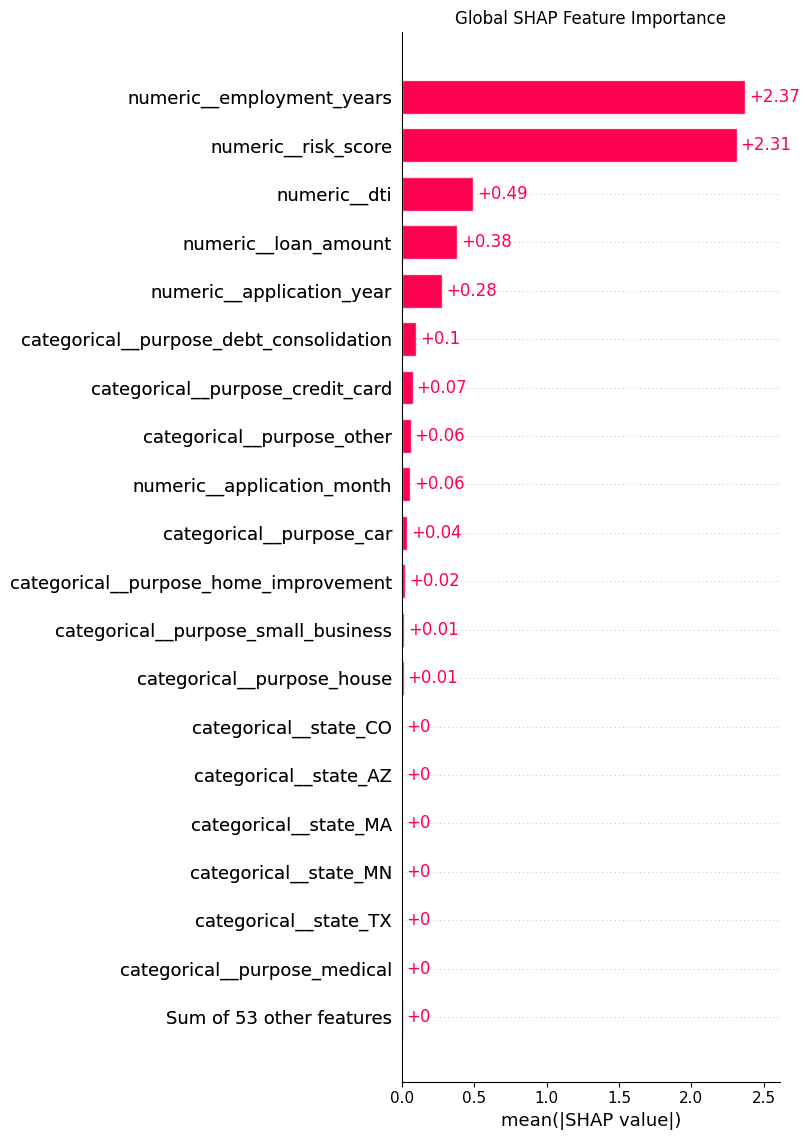

✅ Global SHAP bar plot saved:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/figures/shap_global_bar.png


In [ ]:
# ---------------------------------------------------------
# SHAP Global Bar Plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()

SHAP_BAR_PATH = (
    FIGURE_DIR /
    "shap_global_bar.png"
)

plt.savefig(
    SHAP_BAR_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ Global SHAP bar plot saved:")
print(SHAP_BAR_PATH)

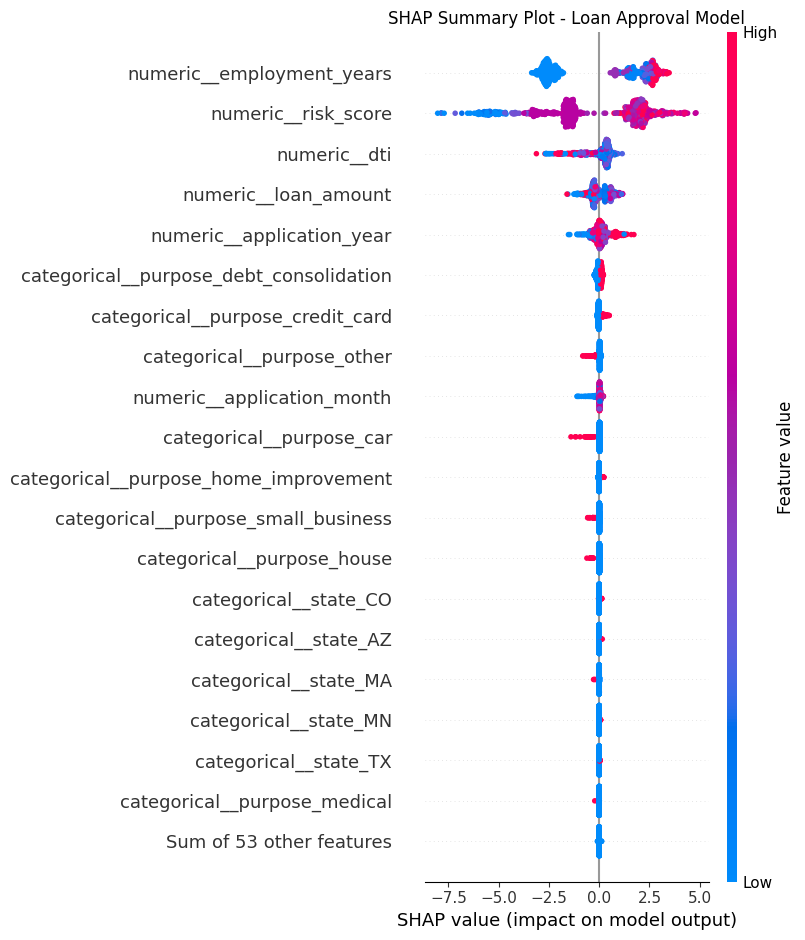

✅ SHAP beeswarm plot saved:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/figures/shap_global_beeswarm.png

Top 10 most influential features:


,Feature,Mean_Absolute_SHAP
0,numeric__employment_years,2.370199
1,numeric__risk_score,2.313015
2,numeric__dti,0.492539
3,numeric__loan_amount,0.384010
4,numeric__application_year,0.280322
5,categorical__purpose_debt_consolidation,0.097011
6,categorical__purpose_credit_card,0.074595
7,categorical__purpose_other,0.060719
8,numeric__application_month,0.056819
9,categorical__purpose_car,0.035132


In [ ]:
# ---------------------------------------------------------
# SHAP Beeswarm Summary Plot
# ---------------------------------------------------------

plt.figure(figsize=(11, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot - Loan Approval Model"
)

plt.tight_layout()

SHAP_BEESWARM_PATH = (
    FIGURE_DIR /
    "shap_global_beeswarm.png"
)

plt.savefig(
    SHAP_BEESWARM_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ SHAP beeswarm plot saved:")
print(SHAP_BEESWARM_PATH)

print("\nTop 10 most influential features:")

display(
    shap_importance_df.head(10)
)

LOCAL SHAP EXPLANATION
Original dataset row: 324544
Actual class: 0
Predicted class: 0
Approval probability: 0.0618

Original application:


,Value
loan_amount,5500.0
risk_score,NaN
dti,11.33
employment_years,5.0
application_year,2017
application_month,2
application_quarter,1
purpose,other
state,MD


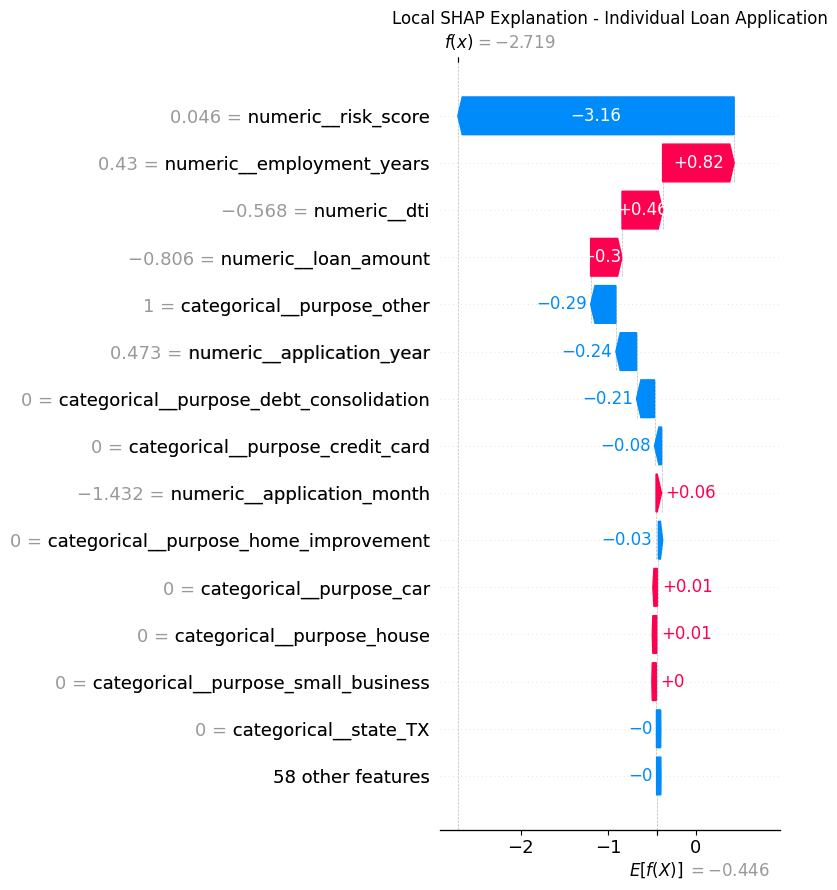


✅ Local SHAP waterfall saved:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/figures/shap_local_waterfall.png


In [ ]:
# ---------------------------------------------------------
# LOCAL SHAP EXPLANATION
# ---------------------------------------------------------

LOCAL_INDEX = 0

local_shap = shap_values[LOCAL_INDEX]

original_row_index = X_shap.index[LOCAL_INDEX]

print("=" * 70)
print("LOCAL SHAP EXPLANATION")
print("=" * 70)

print("Original dataset row:", original_row_index)

print(
    "Actual class:",
    int(y_test.loc[original_row_index])
)

local_original_record = X_test.loc[
    original_row_index
]

local_prediction = best_model.predict(
    pd.DataFrame(
        [local_original_record],
        columns=X_test.columns
    )
)[0]

local_probability = best_model.predict_proba(
    pd.DataFrame(
        [local_original_record],
        columns=X_test.columns
    )
)[0, 1]

print(
    "Predicted class:",
    int(local_prediction)
)

print(
    "Approval probability:",
    round(local_probability, 4)
)

print("\nOriginal application:")
display(
    local_original_record.to_frame(
        name="Value"
    )
)

# ---------------------------------------------------------
# Waterfall plot
# ---------------------------------------------------------

shap.plots.waterfall(
    local_shap,
    max_display=15,
    show=False
)

plt.title(
    "Local SHAP Explanation - Individual Loan Application"
)

plt.tight_layout()

LOCAL_SHAP_PATH = (
    FIGURE_DIR /
    "shap_local_waterfall.png"
)

plt.savefig(
    LOCAL_SHAP_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Local SHAP waterfall saved:")
print(LOCAL_SHAP_PATH)

In [ ]:
# ---------------------------------------------------------
# PREPARE DATA FOR LIME
# ---------------------------------------------------------

# Transform training data with the fitted Experiment 4 preprocessor
X_train_transformed = (
    preprocessor_exp5.transform(
        X_train
    )
)

X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names_shap,
    index=X_train.index
)

# Use a reproducible subset to keep LIME fast
LIME_TRAIN_SIZE = min(
    5000,
    len(X_train_transformed_df)
)

X_lime_train = (
    X_train_transformed_df
    .sample(
        n=LIME_TRAIN_SIZE,
        random_state=42
    )
)

lime_explainer = LimeTabularExplainer(
    training_data=X_lime_train.values,
    feature_names=feature_names_shap,
    class_names=[
        "Rejected",
        "Accepted"
    ],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("=" * 70)
print("LIME EXPLAINER READY")
print("=" * 70)

print(
    "LIME training sample:",
    X_lime_train.shape
)

print(
    "Number of features:",
    len(feature_names_shap)
)

print(
    "\n✅ LIME explainer created successfully."
)

LIME EXPLAINER READY
LIME training sample: (5000, 72)
Number of features: 72

✅ LIME explainer created successfully.


In [ ]:
# ---------------------------------------------------------
# GENERATE LIME EXPLANATION FOR BOTH CLASSES
# ---------------------------------------------------------

lime_instance = X_shap.iloc[
    LOCAL_INDEX
].values

lime_explanation = lime_explainer.explain_instance(
    data_row=lime_instance,
    predict_fn=classifier_exp5.predict_proba,
    num_features=15,
    labels=(0, 1)
)

print("=" * 70)
print("LOCAL LIME EXPLANATION")
print("=" * 70)

print("Application row:", original_row_index)
print("Actual class:", int(y_test.loc[original_row_index]))
print("Predicted class:", int(local_prediction))

print(
    "Predicted approval probability:",
    round(local_probability, 4)
)

print(
    "Predicted rejection probability:",
    round(1 - local_probability, 4)
)

print("\nAvailable LIME labels:")
print(lime_explanation.available_labels())

print("\n✅ LIME explanation generated for both classes.")

LOCAL LIME EXPLANATION
Application row: 324544
Actual class: 0
Predicted class: 0
Predicted approval probability: 0.0618
Predicted rejection probability: 0.9382

Available LIME labels:
[0, 1]

✅ LIME explanation generated for both classes.


In [ ]:
# ---------------------------------------------------------
# EXPLANATION FOR APPROVAL CLASS = 1
# ---------------------------------------------------------

lime_approval_list = lime_explanation.as_list(
    label=1
)

lime_approval_df = pd.DataFrame(
    lime_approval_list,
    columns=[
        "Feature Condition",
        "LIME Weight"
    ]
)

print("=" * 70)
print("LIME EXPLANATION FOR APPROVAL (CLASS 1)")
print("=" * 70)

display(lime_approval_df)


# ---------------------------------------------------------
# EXPLANATION FOR REJECTION CLASS = 0
# ---------------------------------------------------------

lime_rejection_list = lime_explanation.as_list(
    label=0
)

lime_rejection_df = pd.DataFrame(
    lime_rejection_list,
    columns=[
        "Feature Condition",
        "LIME Weight"
    ]
)

print("\n" + "=" * 70)
print("LIME EXPLANATION FOR REJECTION (CLASS 0)")
print("=" * 70)

display(lime_rejection_df)

LIME EXPLANATION FOR APPROVAL (CLASS 1)


,Feature Condition,LIME Weight
0,categorical__state_DC <= 0.00,0.246867
1,categorical__purpose_educational <= 0.00,0.213182
2,categorical__state_ME <= 0.00,0.195765
3,-0.19 < numeric__risk_score <= 0.05,-0.174438
4,categorical__purpose_wedding <= 0.00,0.139058
5,categorical__purpose_car <= 0.00,0.092021
6,categorical__state_MA <= 0.00,0.079443
7,categorical__state_MI <= 0.00,0.076797
8,categorical__state_IN <= 0.00,0.076445
9,categorical__state_ND <= 0.00,-0.074996



LIME EXPLANATION FOR REJECTION (CLASS 0)


,Feature Condition,LIME Weight
0,categorical__state_DC <= 0.00,-0.246867
1,categorical__purpose_educational <= 0.00,-0.213182
2,categorical__state_ME <= 0.00,-0.195765
3,-0.19 < numeric__risk_score <= 0.05,0.174438
4,categorical__purpose_wedding <= 0.00,-0.139058
5,categorical__purpose_car <= 0.00,-0.092021
6,categorical__state_MA <= 0.00,-0.079443
7,categorical__state_MI <= 0.00,-0.076797
8,categorical__state_IN <= 0.00,-0.076445
9,categorical__state_ND <= 0.00,0.074996


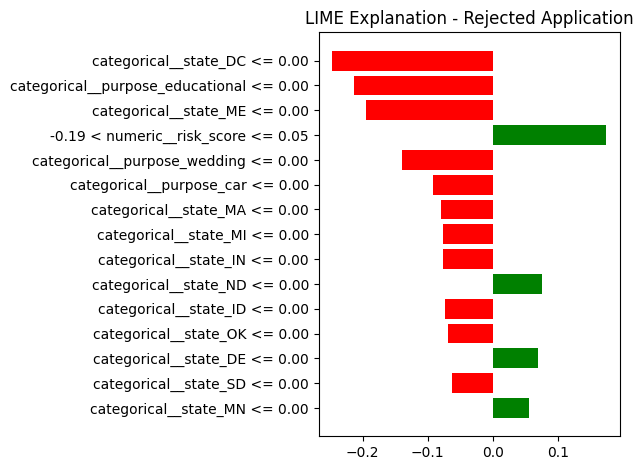

✅ Approval explanation saved:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/local_lime_approval_explanation.csv

✅ Rejection explanation saved:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/local_lime_rejection_explanation.csv

✅ Interactive LIME HTML saved:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/local_lime_explanation.html

✅ LIME plot saved:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/figures/lime_local_explanation.png


In [ ]:
# ---------------------------------------------------------
# SAVE LIME TABLES
# ---------------------------------------------------------

LIME_APPROVAL_PATH = (
    REPORT_DIR /
    "local_lime_approval_explanation.csv"
)

LIME_REJECTION_PATH = (
    REPORT_DIR /
    "local_lime_rejection_explanation.csv"
)

lime_approval_df.to_csv(
    LIME_APPROVAL_PATH,
    index=False
)

lime_rejection_df.to_csv(
    LIME_REJECTION_PATH,
    index=False
)

# ---------------------------------------------------------
# SAVE INTERACTIVE HTML
# ---------------------------------------------------------

LIME_HTML_PATH = (
    REPORT_DIR /
    "local_lime_explanation.html"
)

lime_explanation.save_to_file(
    str(LIME_HTML_PATH)
)

# ---------------------------------------------------------
# PLOT THE ACTUAL PREDICTED CLASS
# ---------------------------------------------------------

predicted_lime_label = int(
    local_prediction
)

fig = lime_explanation.as_pyplot_figure(
    label=predicted_lime_label
)

plt.title(
    f"LIME Explanation - "
    f"{'Accepted' if predicted_lime_label == 1 else 'Rejected'} Application"
)

plt.tight_layout()

LIME_PLOT_PATH = (
    FIGURE_DIR /
    "lime_local_explanation.png"
)

plt.savefig(
    LIME_PLOT_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ Approval explanation saved:")
print(LIME_APPROVAL_PATH)

print("\n✅ Rejection explanation saved:")
print(LIME_REJECTION_PATH)

print("\n✅ Interactive LIME HTML saved:")
print(LIME_HTML_PATH)

print("\n✅ LIME plot saved:")
print(LIME_PLOT_PATH)

In [ ]:
# ---------------------------------------------------------
# FAIRNESS AUDIT SETUP
# ---------------------------------------------------------
# IMPORTANT:
# LendingClub accepted/rejected data does not provide
# true protected attributes such as race or gender.
#
# Therefore, 'state' is used ONLY for a geographic
# group-disparity audit. It is NOT treated as race/gender
# and this analysis must not be interpreted as proof of
# demographic fairness.
# ---------------------------------------------------------

fairness_test_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "state": X_test["state"].fillna("Unknown").values
})

print("=" * 72)
print("FAIRNESS / GROUP AUDIT SETUP")
print("=" * 72)

print("Total test records:", len(fairness_test_df))
print(
    "Number of state groups:",
    fairness_test_df["state"].nunique()
)

print("\nLargest state groups:")
display(
    fairness_test_df["state"]
    .value_counts()
    .head(15)
    .to_frame("Test Records")
)

# ---------------------------------------------------------
# Remove extremely small groups from comparative analysis
# ---------------------------------------------------------

MIN_GROUP_SIZE = 500

state_counts = (
    fairness_test_df["state"]
    .value_counts()
)

eligible_states = state_counts[
    state_counts >= MIN_GROUP_SIZE
].index

fairness_eval_df = fairness_test_df[
    fairness_test_df["state"].isin(
        eligible_states
    )
].copy()

print(
    "\nGroups with at least",
    MIN_GROUP_SIZE,
    "records:",
    len(eligible_states)
)

print(
    "Records included in group audit:",
    len(fairness_eval_df)
)

# ---------------------------------------------------------
# Save methodological limitation
# ---------------------------------------------------------

FAIRNESS_LIMITATION_PATH = (
    REPORT_DIR /
    "fairness_methodology_limitation.txt"
)

fairness_limitation = """
FAIRNESS AUDIT METHODOLOGICAL LIMITATION
========================================

The LendingClub accepted/rejected dataset used in this project does not
contain verified protected demographic attributes such as race or gender.

Therefore, this experiment does NOT perform a demographic fairness audit.

Applicant state is used only as a geographic grouping variable to demonstrate
Fairlearn-based group performance analysis and to identify differences in
model behavior across geographic groups.

State must not be interpreted as a substitute for race, gender, ethnicity,
religion, or any other protected characteristic.

Groups with very small test-set sample sizes are excluded from comparative
metrics because their estimates may be unstable.

Consequently, the results in this experiment demonstrate geographic group
disparity analysis rather than proof of legal, ethical, or demographic fairness.
"""

FAIRNESS_LIMITATION_PATH.write_text(
    fairness_limitation,
    encoding="utf-8"
)

print("\n✅ Fairness methodology documented.")
print(FAIRNESS_LIMITATION_PATH)

FAIRNESS / GROUP AUDIT SETUP
Total test records: 99868
Number of state groups: 51

Largest state groups:


,Test Records
state,
CA,12969
TX,8562
NY,7703
FL,7448
IL,3724
OH,3689
PA,3664
GA,3594
NJ,3338



Groups with at least 500 records: 36
Records included in group audit: 95898

✅ Fairness methodology documented.
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/fairness_methodology_limitation.txt


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

# ---------------------------------------------------------
# Metrics used by Fairlearn
# ---------------------------------------------------------

fairness_metrics = {
    "Accuracy": accuracy_score,

    "Precision": lambda yt, yp:
        precision_score(
            yt,
            yp,
            zero_division=0
        ),

    "Recall_TPR": lambda yt, yp:
        recall_score(
            yt,
            yp,
            zero_division=0
        ),

    "Selection_Rate":
        selection_rate
}

# ---------------------------------------------------------
# MetricFrame
# ---------------------------------------------------------

metric_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=fairness_eval_df["y_true"],
    y_pred=fairness_eval_df["y_pred"],
    sensitive_features=fairness_eval_df["state"]
)

print("=" * 72)
print("OVERALL MODEL METRICS")
print("=" * 72)

display(
    pd.DataFrame(
        metric_frame.overall,
        columns=["Overall"]
    )
)

print("\n" + "=" * 72)
print("METRICS BY STATE")
print("=" * 72)

state_fairness_metrics = (
    metric_frame.by_group
    .reset_index()
)

display(
    state_fairness_metrics.head(20)
)

# Add group sample size
state_fairness_metrics["Group_Size"] = (
    state_fairness_metrics["state"]
    .map(state_counts)
)

# ---------------------------------------------------------
# Fairlearn disparity metrics
# ---------------------------------------------------------

dp_difference = demographic_parity_difference(
    y_true=fairness_eval_df["y_true"],
    y_pred=fairness_eval_df["y_pred"],
    sensitive_features=fairness_eval_df["state"]
)

eo_difference = equalized_odds_difference(
    y_true=fairness_eval_df["y_true"],
    y_pred=fairness_eval_df["y_pred"],
    sensitive_features=fairness_eval_df["state"]
)

print("\n" + "=" * 72)
print("GROUP DISPARITY SUMMARY")
print("=" * 72)

print(
    "Demographic Parity Difference*:",
    round(dp_difference, 4)
)

print(
    "Equalized Odds Difference*:",
    round(eo_difference, 4)
)

print(
    "\n*Here these metrics represent differences across "
    "geographic state groups, not demographic groups."
)

# ---------------------------------------------------------
# Save results
# ---------------------------------------------------------

FAIRNESS_GROUP_PATH = (
    REPORT_DIR /
    "fairness_state_group_metrics.csv"
)

state_fairness_metrics.to_csv(
    FAIRNESS_GROUP_PATH,
    index=False
)

fairness_summary_df = pd.DataFrame({
    "Metric": [
        "Geographic Selection Rate Difference",
        "Geographic Equalized Odds Difference",
        "Minimum Group Size",
        "Number of State Groups"
    ],
    "Value": [
        dp_difference,
        eo_difference,
        MIN_GROUP_SIZE,
        len(eligible_states)
    ]
})

FAIRNESS_SUMMARY_PATH = (
    REPORT_DIR /
    "fairness_audit_summary.csv"
)

fairness_summary_df.to_csv(
    FAIRNESS_SUMMARY_PATH,
    index=False
)

print("\n✅ Fairness group metrics saved.")
print(FAIRNESS_GROUP_PATH)

print("\n✅ Fairness summary saved.")
print(FAIRNESS_SUMMARY_PATH)

OVERALL MODEL METRICS


,Overall
Accuracy,0.963774
Precision,0.959514
Recall_TPR,0.968579
Selection_Rate,0.505860



METRICS BY STATE


,state,Accuracy,Precision,Recall_TPR,Selection_Rate
0,AL,0.970149,0.960568,0.966667,0.411421
1,AR,0.975983,0.970223,0.975062,0.439956
2,AZ,0.963311,0.964316,0.965957,0.526622
3,CA,0.960290,0.959115,0.968472,0.550698
4,CO,0.956432,0.955513,0.962963,0.536307
5,CT,0.959004,0.961140,0.966146,0.565154
6,FL,0.965360,0.958625,0.968918,0.480263
7,GA,0.964663,0.959292,0.965558,0.471619
8,HI,0.952941,0.946058,0.953975,0.472549
9,IL,0.962943,0.961252,0.969925,0.540548



GROUP DISPARITY SUMMARY
Demographic Parity Difference*: 0.2333
Equalized Odds Difference*: 0.0386

*Here these metrics represent differences across geographic state groups, not demographic groups.

✅ Fairness group metrics saved.
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/fairness_state_group_metrics.csv

✅ Fairness summary saved.
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/fairness_audit_summary.csv


HIGHEST SELECTION-RATE STATE GROUPS


,state,Selection_Rate,Accuracy,Recall_TPR,Group_Size
0,MN,0.584646,0.959974,0.970522,1524
1,OR,0.568286,0.957837,0.964401,1091
2,CT,0.565154,0.959004,0.966146,1366
3,NV,0.554226,0.956140,0.967836,1254
4,CA,0.550698,0.960290,0.968472,12969
5,MA,0.546411,0.956561,0.970890,2187
6,IL,0.540548,0.962943,0.969925,3724
7,NY,0.537193,0.964559,0.973304,7703
8,CO,0.536307,0.956432,0.962963,1928
9,NJ,0.535650,0.956261,0.963842,3338



LOWEST SELECTION-RATE STATE GROUPS


,state,Selection_Rate,Accuracy,Recall_TPR,Group_Size
26,GA,0.471619,0.964663,0.965558,3594
27,NC,0.468193,0.965332,0.968705,2971
28,OK,0.452055,0.966732,0.971366,1022
29,AR,0.439956,0.975983,0.975062,916
30,TN,0.436567,0.970149,0.966952,1876
31,KY,0.429701,0.966608,0.974737,1138
32,LA,0.424242,0.971914,0.965278,1353
33,SC,0.413940,0.963727,0.958549,1406
34,AL,0.411421,0.970149,0.966667,1541
35,MS,0.351317,0.981179,0.992565,797


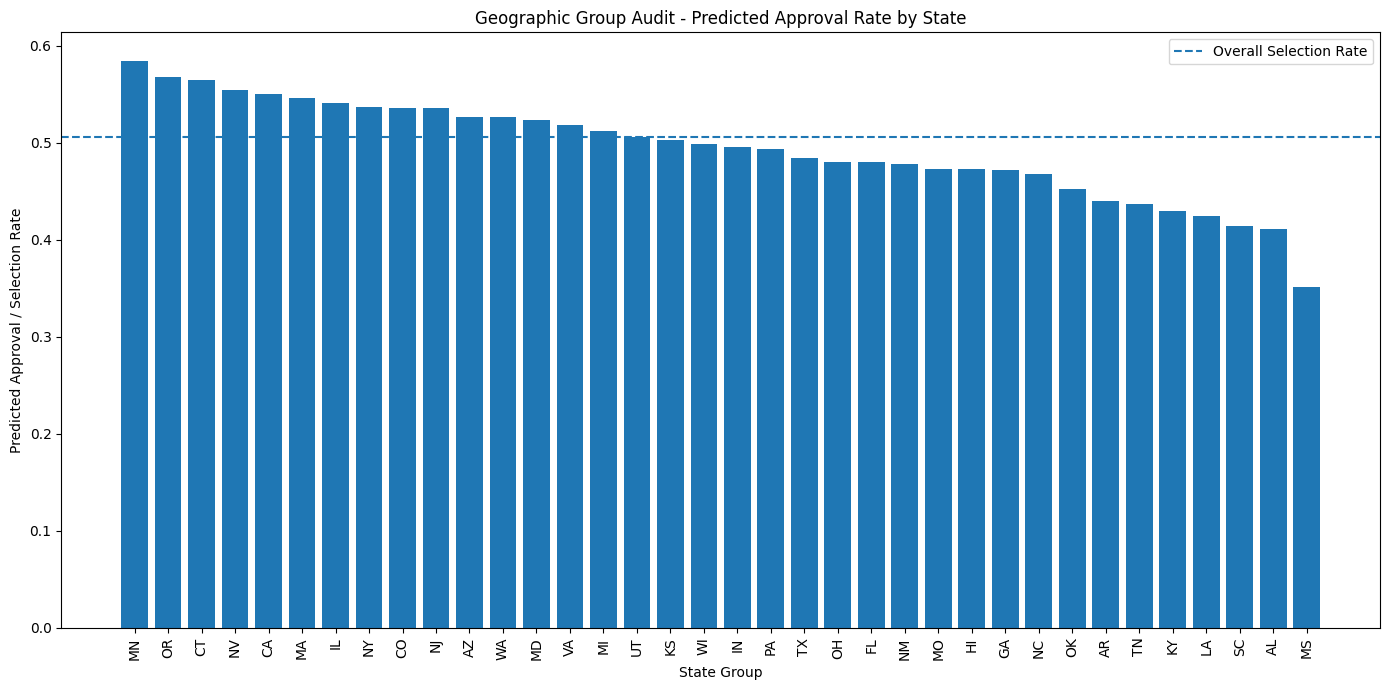

✅ Fairness group plot saved:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/figures/fairness_state_selection_rate.png

NOTE: Differences shown here are geographic group disparities only and must not be interpreted as race/gender fairness results.


In [ ]:
# ---------------------------------------------------------
# Sort by selection rate
# ---------------------------------------------------------

plot_df = (
    state_fairness_metrics
    .sort_values(
        "Selection_Rate",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 72)
print("HIGHEST SELECTION-RATE STATE GROUPS")
print("=" * 72)

display(
    plot_df[
        [
            "state",
            "Selection_Rate",
            "Accuracy",
            "Recall_TPR",
            "Group_Size"
        ]
    ].head(10)
)

print("\n" + "=" * 72)
print("LOWEST SELECTION-RATE STATE GROUPS")
print("=" * 72)

display(
    plot_df[
        [
            "state",
            "Selection_Rate",
            "Accuracy",
            "Recall_TPR",
            "Group_Size"
        ]
    ].tail(10)
)

# ---------------------------------------------------------
# Plot selection rates
# ---------------------------------------------------------

plt.figure(
    figsize=(14, 7)
)

plt.bar(
    plot_df["state"],
    plot_df["Selection_Rate"]
)

plt.axhline(
    metric_frame.overall["Selection_Rate"],
    linestyle="--",
    label="Overall Selection Rate"
)

plt.xlabel("State Group")
plt.ylabel("Predicted Approval / Selection Rate")

plt.title(
    "Geographic Group Audit - Predicted Approval Rate by State"
)

plt.xticks(
    rotation=90
)

plt.legend()

plt.tight_layout()

FAIRNESS_PLOT_PATH = (
    FIGURE_DIR /
    "fairness_state_selection_rate.png"
)

plt.savefig(
    FAIRNESS_PLOT_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ Fairness group plot saved:")
print(FAIRNESS_PLOT_PATH)

print(
    "\nNOTE: Differences shown here are geographic "
    "group disparities only and must not be interpreted "
    "as race/gender fairness results."
)

In [ ]:
from fairlearn.postprocessing import ThresholdOptimizer

# ---------------------------------------------------------
# Prepare geographic groups for mitigation
# ---------------------------------------------------------

A_train = (
    X_train["state"]
    .fillna("Unknown")
    .astype(str)
)

A_test = (
    X_test["state"]
    .fillna("Unknown")
    .astype(str)
)

# Use only sufficiently large groups selected earlier
train_mask = A_train.isin(
    eligible_states
)

test_mask = A_test.isin(
    eligible_states
)

X_train_mit = X_train.loc[
    train_mask
].copy()

y_train_mit = y_train.loc[
    X_train_mit.index
].copy()

A_train_mit = A_train.loc[
    X_train_mit.index
].copy()

X_test_mit = X_test.loc[
    test_mask
].copy()

y_test_mit = y_test.loc[
    X_test_mit.index
].copy()

A_test_mit = A_test.loc[
    X_test_mit.index
].copy()

print("=" * 72)
print("FAIRLEARN BIAS MITIGATION SETUP")
print("=" * 72)

print(
    "Mitigation training records:",
    len(X_train_mit)
)

print(
    "Mitigation testing records:",
    len(X_test_mit)
)

print(
    "State groups:",
    A_train_mit.nunique()
)

# ---------------------------------------------------------
# Threshold Optimizer
# ---------------------------------------------------------

mitigated_model = ThresholdOptimizer(
    estimator=best_model,
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True,
    predict_method="predict_proba"
)

mitigated_model.fit(
    X_train_mit,
    y_train_mit,
    sensitive_features=A_train_mit
)

print(
    "\n✅ Fairlearn ThresholdOptimizer fitted."
)

print(
    "Constraint: Equalized Odds"
)

print(
    "Objective: Balanced Accuracy"
)

print(
    "\nNOTE: This mitigation concerns geographic "
    "state groups only."
)

FAIRLEARN BIAS MITIGATION SETUP
Mitigation training records: 383844
Mitigation testing records: 95898
State groups: 36

✅ Fairlearn ThresholdOptimizer fitted.
Constraint: Equalized Odds
Objective: Balanced Accuracy

NOTE: This mitigation concerns geographic state groups only.


In [ ]:
from fairlearn.postprocessing import ThresholdOptimizer

# ---------------------------------------------------------
# Prepare geographic groups for mitigation
# ---------------------------------------------------------

A_train = (
    X_train["state"]
    .fillna("Unknown")
    .astype(str)
)

A_test = (
    X_test["state"]
    .fillna("Unknown")
    .astype(str)
)

# Use only sufficiently large groups selected earlier
train_mask = A_train.isin(
    eligible_states
)

test_mask = A_test.isin(
    eligible_states
)

X_train_mit = X_train.loc[
    train_mask
].copy()

y_train_mit = y_train.loc[
    X_train_mit.index
].copy()

A_train_mit = A_train.loc[
    X_train_mit.index
].copy()

X_test_mit = X_test.loc[
    test_mask
].copy()

y_test_mit = y_test.loc[
    X_test_mit.index
].copy()

A_test_mit = A_test.loc[
    X_test_mit.index
].copy()

print("=" * 72)
print("FAIRLEARN BIAS MITIGATION SETUP")
print("=" * 72)

print(
    "Mitigation training records:",
    len(X_train_mit)
)

print(
    "Mitigation testing records:",
    len(X_test_mit)
)

print(
    "State groups:",
    A_train_mit.nunique()
)

# ---------------------------------------------------------
# Threshold Optimizer
# ---------------------------------------------------------

mitigated_model = ThresholdOptimizer(
    estimator=best_model,
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True,
    predict_method="predict_proba"
)

mitigated_model.fit(
    X_train_mit,
    y_train_mit,
    sensitive_features=A_train_mit
)

print(
    "\n✅ Fairlearn ThresholdOptimizer fitted."
)

print(
    "Constraint: Equalized Odds"
)

print(
    "Objective: Balanced Accuracy"
)

print(
    "\nNOTE: This mitigation concerns geographic "
    "state groups only."
)

FAIRLEARN BIAS MITIGATION SETUP
Mitigation training records: 383844
Mitigation testing records: 95898
State groups: 36

✅ Fairlearn ThresholdOptimizer fitted.
Constraint: Equalized Odds
Objective: Balanced Accuracy

NOTE: This mitigation concerns geographic state groups only.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

print("=" * 72)
print("RECREATING MITIGATION COMPARISON")
print("=" * 72)

# Original model
before_pred = best_model.predict(
    X_test_mit
)

# Fairlearn mitigated model
after_pred = mitigated_model.predict(
    X_test_mit,
    sensitive_features=A_test_mit,
    random_state=42
)

print("Test records:", len(y_test_mit))
print("Before predictions:", len(before_pred))
print("After predictions :", len(after_pred))

print("\n✅ Before/after predictions generated.")

RECREATING MITIGATION COMPARISON
Test records: 95898
Before predictions: 95898
After predictions : 95898

✅ Before/after predictions generated.


In [ ]:
# ---------------------------------------------------------
# PERFORMANCE METRICS
# ---------------------------------------------------------

before_metrics = {
    "Accuracy": accuracy_score(
        y_test_mit, before_pred
    ),

    "Precision": precision_score(
        y_test_mit,
        before_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test_mit,
        before_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_test_mit,
        before_pred,
        zero_division=0
    ),

    "Balanced_Accuracy": balanced_accuracy_score(
        y_test_mit,
        before_pred
    )
}

after_metrics = {
    "Accuracy": accuracy_score(
        y_test_mit, after_pred
    ),

    "Precision": precision_score(
        y_test_mit,
        after_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test_mit,
        after_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_test_mit,
        after_pred,
        zero_division=0
    ),

    "Balanced_Accuracy": balanced_accuracy_score(
        y_test_mit,
        after_pred
    )
}

performance_comparison = pd.DataFrame({
    "Before_Mitigation": before_metrics,
    "After_Mitigation": after_metrics
})

print("=" * 72)
print("PERFORMANCE BEFORE VS AFTER MITIGATION")
print("=" * 72)

display(performance_comparison)


# ---------------------------------------------------------
# GROUP DISPARITY METRICS
# ---------------------------------------------------------

before_dp = demographic_parity_difference(
    y_true=y_test_mit,
    y_pred=before_pred,
    sensitive_features=A_test_mit
)

after_dp = demographic_parity_difference(
    y_true=y_test_mit,
    y_pred=after_pred,
    sensitive_features=A_test_mit
)

before_eo = equalized_odds_difference(
    y_true=y_test_mit,
    y_pred=before_pred,
    sensitive_features=A_test_mit
)

after_eo = equalized_odds_difference(
    y_true=y_test_mit,
    y_pred=after_pred,
    sensitive_features=A_test_mit
)

disparity_comparison = pd.DataFrame({
    "Metric": [
        "Geographic Selection Rate Difference",
        "Geographic Equalized Odds Difference"
    ],

    "Before_Mitigation": [
        before_dp,
        before_eo
    ],

    "After_Mitigation": [
        after_dp,
        after_eo
    ]
})

print("\n" + "=" * 72)
print("GEOGRAPHIC GROUP DISPARITY")
print("=" * 72)

display(disparity_comparison)

print(
    "\nEqualized Odds Difference Before:",
    round(before_eo, 4)
)

print(
    "Equalized Odds Difference After :",
    round(after_eo, 4)
)

print(
    "Change:",
    round(before_eo - after_eo, 4)
)

PERFORMANCE BEFORE VS AFTER MITIGATION


,Before_Mitigation,After_Mitigation
Accuracy,0.963774,0.959280
Precision,0.959514,0.953474
Recall,0.968579,0.965874
F1,0.964025,0.959634
Balanced_Accuracy,0.963763,0.959265



GEOGRAPHIC GROUP DISPARITY


,Metric,Before_Mitigation,After_Mitigation
0,Geographic Selection Rate Difference,0.233328,0.214565
1,Geographic Equalized Odds Difference,0.038590,0.052076



Equalized Odds Difference Before: 0.0386
Equalized Odds Difference After : 0.0521
Change: -0.0135


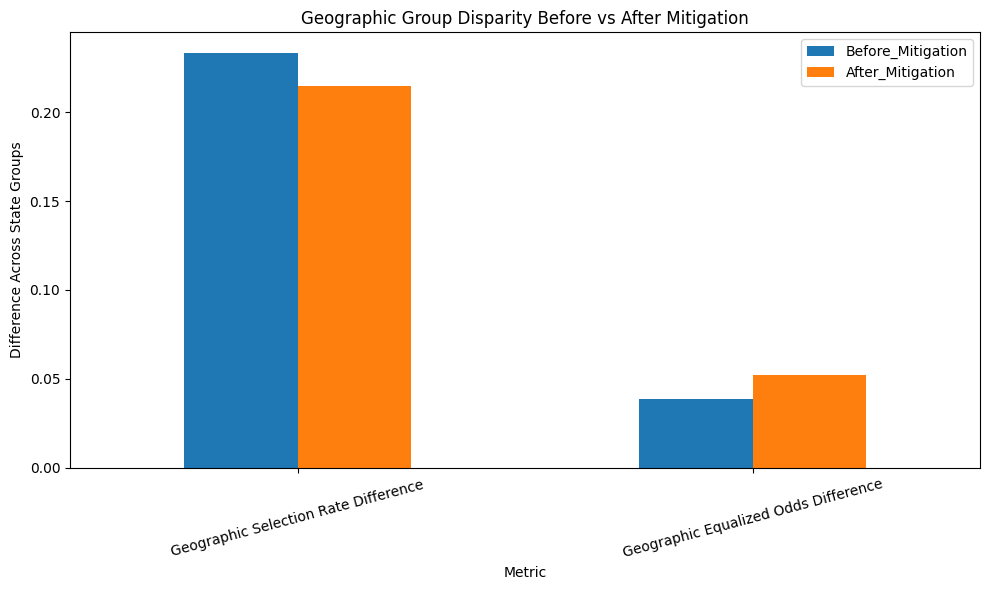

BIAS MITIGATION DELIVERABLES SAVED
✅ /content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/mitigation_performance_comparison.csv
✅ /content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/mitigation_disparity_comparison.csv
✅ /content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/fairness_state_metrics_after_mitigation.csv
✅ /content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/reports/exp5/figures/fairness_before_after_mitigation.png

⚠️ This is geographic state-group mitigation, not proof of demographic fairness.


In [ ]:
# ---------------------------------------------------------
# SAVE PERFORMANCE/DISPARITY TABLES
# ---------------------------------------------------------

PERFORMANCE_COMPARISON_PATH = (
    REPORT_DIR /
    "mitigation_performance_comparison.csv"
)

DISPARITY_COMPARISON_PATH = (
    REPORT_DIR /
    "mitigation_disparity_comparison.csv"
)

performance_comparison.to_csv(
    PERFORMANCE_COMPARISON_PATH
)

disparity_comparison.to_csv(
    DISPARITY_COMPARISON_PATH,
    index=False
)


# ---------------------------------------------------------
# POST-MITIGATION GROUP METRICS
# ---------------------------------------------------------

after_metric_frame = MetricFrame(
    metrics={
        "Accuracy": accuracy_score,

        "Recall_TPR": lambda yt, yp:
            recall_score(
                yt,
                yp,
                zero_division=0
            ),

        "Selection_Rate": selection_rate
    },

    y_true=y_test_mit,
    y_pred=after_pred,
    sensitive_features=A_test_mit
)

after_group_metrics = (
    after_metric_frame
    .by_group
    .reset_index()
)

AFTER_GROUP_PATH = (
    REPORT_DIR /
    "fairness_state_metrics_after_mitigation.csv"
)

after_group_metrics.to_csv(
    AFTER_GROUP_PATH,
    index=False
)


# ---------------------------------------------------------
# BEFORE VS AFTER PLOT
# ---------------------------------------------------------

plot_comparison = disparity_comparison.set_index(
    "Metric"
)[[
    "Before_Mitigation",
    "After_Mitigation"
]]

ax = plot_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Geographic Group Disparity Before vs After Mitigation"
)

plt.ylabel(
    "Difference Across State Groups"
)

plt.xlabel(
    "Metric"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

MITIGATION_PLOT_PATH = (
    FIGURE_DIR /
    "fairness_before_after_mitigation.png"
)

plt.savefig(
    MITIGATION_PLOT_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("=" * 72)
print("BIAS MITIGATION DELIVERABLES SAVED")
print("=" * 72)

print("✅", PERFORMANCE_COMPARISON_PATH)
print("✅", DISPARITY_COMPARISON_PATH)
print("✅", AFTER_GROUP_PATH)
print("✅", MITIGATION_PLOT_PATH)

print(
    "\n⚠️ This is geographic state-group mitigation, "
    "not proof of demographic fairness."
)

In [ ]:
# ---------------------------------------------------------
# EXPERIMENT 5 CONCLUSION
# ---------------------------------------------------------

top_shap_features = (
    shap_importance_df
    .head(10)["Feature"]
    .tolist()
)

exp5_conclusion = f"""
EXPERIMENT 5 - EXPLAINABLE AI AND FAIRNESS ANALYSIS
======================================================================

1. EXPLAINABILITY
-----------------
SHAP was used for global and local model explainability.

The most influential transformed features identified by SHAP included:
{", ".join(top_shap_features)}

A SHAP bar plot and beeswarm plot were generated to explain overall
model behavior.

A local SHAP waterfall plot was also generated to explain an individual
loan application.

LIME was used as an additional local explanation technique.
Separate explanations were generated for the Accepted and Rejected classes.

2. FAIRNESS / GROUP AUDIT
-------------------------
The LendingClub accepted/rejected dataset does not contain verified
protected demographic attributes such as race or gender.

Therefore, demographic fairness cannot be directly evaluated using this
dataset.

Applicant state was used only as a geographic grouping variable to
demonstrate Fairlearn-based group analysis.

Before mitigation:

Geographic Selection Rate Difference =
{before_dp:.4f}

Geographic Equalized Odds Difference =
{before_eo:.4f}

3. BIAS MITIGATION
------------------
Fairlearn ThresholdOptimizer was applied using an Equalized Odds
constraint.

After mitigation:

Geographic Selection Rate Difference =
{after_dp:.4f}

Geographic Equalized Odds Difference =
{after_eo:.4f}

Equalized Odds Difference Change =
{before_eo - after_eo:.4f}

Model performance before mitigation:

Accuracy = {before_metrics["Accuracy"]:.4f}
Precision = {before_metrics["Precision"]:.4f}
Recall = {before_metrics["Recall"]:.4f}
F1 Score = {before_metrics["F1"]:.4f}
Balanced Accuracy = {before_metrics["Balanced_Accuracy"]:.4f}

Model performance after mitigation:

Accuracy = {after_metrics["Accuracy"]:.4f}
Precision = {after_metrics["Precision"]:.4f}
Recall = {after_metrics["Recall"]:.4f}
F1 Score = {after_metrics["F1"]:.4f}
Balanced Accuracy = {after_metrics["Balanced_Accuracy"]:.4f}

4. FINAL INTERPRETATION
-----------------------
Experiment 5 demonstrates how model predictions can be explained using
SHAP and LIME and how Fairlearn can be used to identify and mitigate
differences in model behavior across groups.

The fairness results must be interpreted strictly as geographic
state-group analysis.

State is not treated as a substitute for race, gender, ethnicity or any
other protected attribute, and these results do not establish legal or
demographic fairness.
"""

CONCLUSION_PATH = (
    REPORT_DIR /
    "experiment_5_conclusion.txt"
)

CONCLUSION_PATH.write_text(
    exp5_conclusion,
    encoding="utf-8"
)

print(exp5_conclusion)

print("\n✅ Experiment 5 conclusion saved:")
print(CONCLUSION_PATH)


EXPERIMENT 5 - EXPLAINABLE AI AND FAIRNESS ANALYSIS

1. EXPLAINABILITY
-----------------
SHAP was used for global and local model explainability.

The most influential transformed features identified by SHAP included:
numeric__employment_years, numeric__risk_score, numeric__dti, numeric__loan_amount, numeric__application_year, categorical__purpose_debt_consolidation, categorical__purpose_credit_card, categorical__purpose_other, numeric__application_month, categorical__purpose_car

A SHAP bar plot and beeswarm plot were generated to explain overall
model behavior.

A local SHAP waterfall plot was also generated to explain an individual
loan application.

LIME was used as an additional local explanation technique.
Separate explanations were generated for the Accepted and Rejected classes.

2. FAIRNESS / GROUP AUDIT
-------------------------
The LendingClub accepted/rejected dataset does not contain verified
protected demographic attributes such as race or gender.

Therefore, demographic

In [ ]:
# ---------------------------------------------------------
# EXPERIMENT 5 CONCLUSION
# ---------------------------------------------------------

top_shap_features = (
    shap_importance_df
    .head(10)["Feature"]
    .tolist()
)

exp5_conclusion = f"""
EXPERIMENT 5 - EXPLAINABLE AI AND FAIRNESS ANALYSIS
======================================================================

1. EXPLAINABILITY
-----------------
SHAP was used for global and local model explainability.

The most influential transformed features identified by SHAP included:
{", ".join(top_shap_features)}

A SHAP bar plot and beeswarm plot were generated to explain overall
model behavior.

A local SHAP waterfall plot was also generated to explain an individual
loan application.

LIME was used as an additional local explanation technique.
Separate explanations were generated for the Accepted and Rejected classes.

2. FAIRNESS / GROUP AUDIT
-------------------------
The LendingClub accepted/rejected dataset does not contain verified
protected demographic attributes such as race or gender.

Therefore, demographic fairness cannot be directly evaluated using this
dataset.

Applicant state was used only as a geographic grouping variable to
demonstrate Fairlearn-based group analysis.

Before mitigation:

Geographic Selection Rate Difference =
{before_dp:.4f}

Geographic Equalized Odds Difference =
{before_eo:.4f}

3. BIAS MITIGATION
------------------
Fairlearn ThresholdOptimizer was applied using an Equalized Odds
constraint.

After mitigation:

Geographic Selection Rate Difference =
{after_dp:.4f}

Geographic Equalized Odds Difference =
{after_eo:.4f}

Equalized Odds Difference Change =
{before_eo - after_eo:.4f}

Model performance before mitigation:

Accuracy = {before_metrics["Accuracy"]:.4f}
Precision = {before_metrics["Precision"]:.4f}
Recall = {before_metrics["Recall"]:.4f}
F1 Score = {before_metrics["F1"]:.4f}
Balanced Accuracy = {before_metrics["Balanced_Accuracy"]:.4f}

Model performance after mitigation:

Accuracy = {after_metrics["Accuracy"]:.4f}
Precision = {after_metrics["Precision"]:.4f}
Recall = {after_metrics["Recall"]:.4f}
F1 Score = {after_metrics["F1"]:.4f}
Balanced Accuracy = {after_metrics["Balanced_Accuracy"]:.4f}

4. FINAL INTERPRETATION
-----------------------
Experiment 5 demonstrates how model predictions can be explained using
SHAP and LIME and how Fairlearn can be used to identify and mitigate
differences in model behavior across groups.

The fairness results must be interpreted strictly as geographic
state-group analysis.

State is not treated as a substitute for race, gender, ethnicity or any
other protected attribute, and these results do not establish legal or
demographic fairness.
"""

CONCLUSION_PATH = (
    REPORT_DIR /
    "experiment_5_conclusion.txt"
)

CONCLUSION_PATH.write_text(
    exp5_conclusion,
    encoding="utf-8"
)

print(exp5_conclusion)

print("\n✅ Experiment 5 conclusion saved:")
print(CONCLUSION_PATH)


EXPERIMENT 5 - EXPLAINABLE AI AND FAIRNESS ANALYSIS

1. EXPLAINABILITY
-----------------
SHAP was used for global and local model explainability.

The most influential transformed features identified by SHAP included:
numeric__employment_years, numeric__risk_score, numeric__dti, numeric__loan_amount, numeric__application_year, categorical__purpose_debt_consolidation, categorical__purpose_credit_card, categorical__purpose_other, numeric__application_month, categorical__purpose_car

A SHAP bar plot and beeswarm plot were generated to explain overall
model behavior.

A local SHAP waterfall plot was also generated to explain an individual
loan application.

LIME was used as an additional local explanation technique.
Separate explanations were generated for the Accepted and Rejected classes.

2. FAIRNESS / GROUP AUDIT
-------------------------
The LendingClub accepted/rejected dataset does not contain verified
protected demographic attributes such as race or gender.

Therefore, demographic

In [ ]:
from pathlib import Path
import shutil

# Correct target location
EXP5_NOTEBOOK = (
    PROJECT_ROOT /
    "ADS_EXP_5.ipynb"
)

print("Expected notebook:")
print(EXP5_NOTEBOOK)

# If already there, use it
if EXP5_NOTEBOOK.exists():

    print("\n✅ ADS_EXP_5.ipynb already exists in project folder.")

else:

    print("\n⚠️ Notebook not found in project folder.")
    print("Searching mounted Google Drive...")

    # Search for an exact ADS_EXP_5.ipynb copy elsewhere
    search_root = DRIVE_MOUNT if "DRIVE_MOUNT" in globals() else Path("/content")

    matches = list(
        search_root.rglob("ADS_EXP_5.ipynb")
    )

    # Exclude target itself
    matches = [
        p for p in matches
        if p.resolve() != EXP5_NOTEBOOK.resolve()
    ]

    if matches:

        print("\nFound:")
        for path in matches:
            print("•", path)

        # Copy exact matching notebook to project folder
        shutil.copy2(
            matches[0],
            EXP5_NOTEBOOK
        )

        print("\n✅ Notebook copied to project folder.")

    else:

        print(
            "\n❌ ADS_EXP_5.ipynb was not found."
        )

        print(
            "\nSave the CURRENT Colab notebook as:"
        )

        print(
            "ADS_EXP_5.ipynb"
        )

        print(
            "\ninside your Applied Data Science Project folder."
        )

print(
    "\nFinal notebook exists:",
    EXP5_NOTEBOOK.exists()
)

Expected notebook:
/content/drive_exp5/.shortcut-targets-by-id/1Qa-0wb-sSO4lC_krs-UYMHB3HiVqPSjL/Applied Data Science Project/ADS_EXP_5.ipynb

⚠️ Notebook not found in project folder.
Searching mounted Google Drive...

❌ ADS_EXP_5.ipynb was not found.

Save the CURRENT Colab notebook as:
ADS_EXP_5.ipynb

inside your Applied Data Science Project folder.

Final notebook exists: False


In [ ]:
import os
import subprocess

os.chdir(PROJECT_ROOT)

if not EXP5_NOTEBOOK.exists():

    raise FileNotFoundError(
        "ADS_EXP_5.ipynb is still missing. "
        "Save the current notebook into the project folder first."
    )

# Stage Experiment 5 notebook and reports
subprocess.run(
    [
        "git",
        "add",
        "ADS_EXP_5.ipynb",
        "reports/exp5/"
    ],
    check=True
)

print("=" * 70)
print("STAGED EXPERIMENT 5 FILES")
print("=" * 70)

subprocess.run(
    [
        "git",
        "status",
        "--short"
    ]
)

# Commit
commit = subprocess.run(
    [
        "git",
        "commit",
        "-m",
        "Complete Experiment 5 - SHAP LIME fairness audit and bias mitigation"
    ],
    capture_output=True,
    text=True
)

print("\n" + "=" * 70)
print("COMMIT RESULT")
print("=" * 70)

print(commit.stdout)

if commit.stderr:
    print(commit.stderr)

print("\nLatest commits:")

subprocess.run(
    [
        "git",
        "log",
        "--oneline",
        "-3"
    ]
)

FileNotFoundError: ADS_EXP_5.ipynb is still missing. Save the current notebook into the project folder first.

In [4]:
import shutil

# Search all Drive notebooks whose name contains EXP and 5
matches = [
    p for p in DRIVE_MOUNT.rglob("*.ipynb")
    if "exp" in p.name.lower()
    and "5" in p.name.lower()
]

print("Possible Experiment 5 notebooks found:", len(matches))

for i, p in enumerate(matches, 1):
    print(i, p)

if matches:

    # Prefer exact ADS_EXP_5.ipynb if available
    exact = [
        p for p in matches
        if p.name.lower() == "ads_exp_5.ipynb"
    ]

    source = exact[0] if exact else matches[0]

    print("\nUsing:")
    print(source)

    if source.resolve() != EXP5_NOTEBOOK.resolve():

        shutil.copy2(
            source,
            EXP5_NOTEBOOK
        )

    print(
        "\n✅ Final notebook exists:",
        EXP5_NOTEBOOK.exists()
    )

    print(
        "Size:",
        round(
            EXP5_NOTEBOOK.stat().st_size
            / (1024 * 1024),
            2
        ),
        "MB"
    )

else:

    print(
        "\n❌ No Experiment 5 notebook found in Drive."
    )

Possible Experiment 5 notebooks found: 10
1 /content/exp5_drive/MyDrive/Colab Notebooks/ADS_EXP_5.ipynb
2 /content/exp5_drive/MyDrive/Classroom/NLP SEM 6 2025-26 A and B/ANSH THAKUR SANJEEV - PCE NLP EXP 1 25-26 SEM 6.ipynb
3 /content/exp5_drive/MyDrive/Classroom/NLP SEM 6 2025-26 A and B/ANSH THAKUR SANJEEV - PCE NLP EXP 2 25-26 SEM 6 (1).ipynb
4 /content/exp5_drive/MyDrive/Classroom/NLP SEM 6 2025-26 A and B/ANSH THAKUR SANJEEV - PCE NLP EXP 3 25-26 SEM 6.ipynb
5 /content/exp5_drive/MyDrive/Classroom/NLP SEM 6 2025-26 A and B/ANSH THAKUR SANJEEV - PCE NLP EXP 2 25-26 SEM 6.ipynb
6 /content/exp5_drive/MyDrive/Classroom/NLP SEM 6 2025-26 A and B/ANSH THAKUR SANJEEV - PCE NLP EXP 4 25-26 SEM 6.ipynb
7 /content/exp5_drive/MyDrive/Classroom/NLP SEM 6 2025-26 A and B/ANSH THAKUR SANJEEV - PCE NLP EXP 5 25-26 SEM 6.ipynb
8 /content/exp5_drive/MyDrive/Classroom/NLP SEM 6 2025-26 A and B/ANSH THAKUR SANJEEV - PCE NLP EXP 7 25-26 SEM 6.ipynb
9 /content/exp5_drive/MyDrive/Classroom/NLP SEM 6 20